In [1]:
from datasets import load_dataset
from collections import Counter, defaultdict
import math
from nltk.tokenize import word_tokenize, sent_tokenize
import pandas as pd

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score,precision_score,recall_score,f1_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.ensemble import VotingClassifier
import matplotlib.pyplot as plt
from collections import Counter
import tiktoken
import seaborn as sns
from spacy.lang.fr.stop_words import STOP_WORDS as fr_stop
from spacy.lang.en.stop_words import STOP_WORDS as en_stop
from nltk import word_tokenize          
from nltk.stem import WordNetLemmatizer 
import nltk
import pandas as pd
from nltk import word_tokenize
from nltk.lm import Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.translate.bleu_score import sentence_bleu
from rouge import Rouge

/home/alexis/epita/project_nlp/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'rouge'

In [10]:
# Variable
percentage_genre_to_keep = 25


In [11]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)


In [12]:
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
print(df_filtered_one_genre.shape)
df_filtered_one_genre.head()

(8753, 31)


,Script,Title,imdb_action,imdb_adventure,imdb_animation,imdb_biography,imdb_comedy,imdb_crime,imdb_documentary,imdb_drama,...,imdb_romance,imdb_sci-fi,imdb_short,imdb_sport,imdb_talk-show,imdb_thriller,imdb_war,imdb_western,imdb_adult,genre_count
0,So what's goin' on?\n Where's my brother?\n So...,Beyond the Dunwich Horror (2008),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,"Like this?\n Good.\n Okay, that's good.\n Righ...",Beyond the Gates (2016),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
5,1\n Beyond the hills\n Stay there!\n Voichita!...,Beyond the Hills (2012),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
23,"Sir, this place is so dusty.\n Hmm.\n Your cho...",Bhagavan Dasante Ramrajyam (2023),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
28,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",Bhairathi Ranagal (2024),NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [13]:
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
df_filtered_one_genre['filtered_genre']


/tmp/ipykernel_6771/707917607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


0             imdb_horror
3              imdb_drama
5              imdb_drama
23             imdb_drama
28             imdb_drama
               ...       
38115          imdb_drama
38123    imdb_documentary
38125          imdb_drama
38133      imdb_adventure
38134          imdb_drama
Name: filtered_genre, Length: 8753, dtype: object

In [14]:
df_filtered_one_genre['filtered_genre'].value_counts()


filtered_genre
imdb_drama          2948
imdb_comedy         1622
imdb_documentary    1301
imdb_horror          944
imdb_thriller        643
imdb_romance         262
imdb_action          242
imdb_western         112
imdb_family          112
imdb_sci-fi           79
imdb_crime            61
imdb_animation        56
imdb_talk-show        51
imdb_music            50
imdb_short            49
imdb_mystery          49
imdb_adventure        37
imdb_fantasy          27
imdb_reality-tv       21
imdb_musical          21
imdb_war              16
imdb_biography        16
imdb_sport            12
imdb_game-show         8
imdb_news              8
imdb_history           6
Name: count, dtype: int64

/tmp/ipykernel_6771/3269823211.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")


Text(0, 0.5, 'Genres')

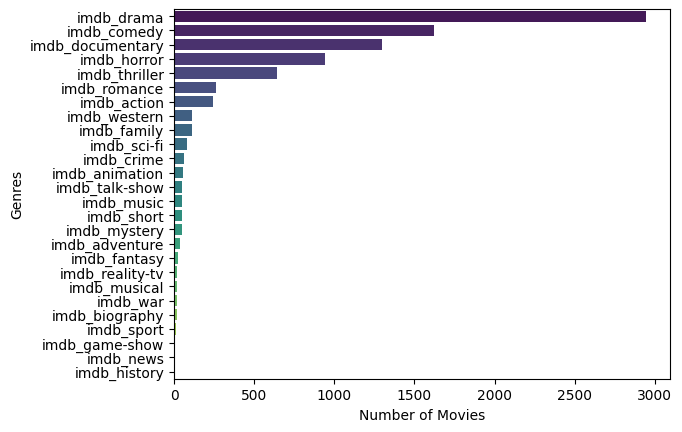

In [15]:

df_counts = df_filtered_one_genre['filtered_genre'].value_counts().reset_index()
df_counts.columns = ['Genre', 'Count']

sns.barplot(x='Count', y='Genre', data=df_counts, palette="viridis")

plt.xlabel('Number of Movies')
plt.ylabel('Genres')


In [16]:
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])

In [17]:
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

for genre,number in sorted_list:
    print(f"Genre: {genre}, number of samples: {number}")

genre_to_keep = [genre for genre,_ in sorted_list]
genre_to_keep

Genre: imdb_drama, number of samples: 2948
Genre: imdb_comedy, number of samples: 1622
Genre: imdb_documentary, number of samples: 1301
Genre: imdb_horror, number of samples: 944
Genre: imdb_thriller, number of samples: 643
Genre: imdb_romance, number of samples: 262


['imdb_drama',
 'imdb_comedy',
 'imdb_documentary',
 'imdb_horror',
 'imdb_thriller',
 'imdb_romance']

In [18]:
columns_to_keep = ['Script','filtered_genre']

df_filtered_one_genre_to_train = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_filtered_one_genre_to_train = df_filtered_one_genre_to_train[columns_to_keep].reset_index(drop=True)
df_filtered_one_genre_to_train

,Script,filtered_genre
0,So what's goin' on?\n Where's my brother?\n So...,imdb_horror
1,"Like this?\n Good.\n Okay, that's good.\n Righ...",imdb_drama
2,1\n Beyond the hills\n Stay there!\n Voichita!...,imdb_drama
3,"Sir, this place is so dusty.\n Hmm.\n Your cho...",imdb_drama
4,"1\n 'Ronapura's own living God, Bhairathi\n Ra...",imdb_drama
...,...,...
7715,"Here in Malaysia, there is an almost\n overwhe...",imdb_comedy
7716,"Okay, let's go for a take\n Get ready to carry...",imdb_drama
7717,Turn left.\n Make a right.\n Is this the kitch...,imdb_documentary
7718,Are you going somewhere? No?\n Last week I was...,imdb_drama


In [19]:
df_train,df_test = train_test_split(df_filtered_one_genre_to_train,test_size=0.1,random_state=42)


In [20]:
X_train,X_test,y_train,y_test = df_train['Script'],df_test['Script'],df_train['filtered_genre'],df_test['filtered_genre']


In [ ]:
X_train_tok = [word_tokenize(script) for script in X_train]
X_test_tok = [word_tokenize(script) for script in X_test]

In [ ]:
n = 3
train_data, vocab = padded_everygram_pipeline(n, X_train_tok)
model = Laplace(n)
model.fit(train_data, vocab)